In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import missingno as msno
import warnings
from sklearn.preprocessing import LabelEncoder
!pip install geopandas
import geopandas as gpd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")



[notice] A new release of pip is available: 25.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


In [5]:
df=pd.read_csv("earthquake_data_tsunami.csv")

In [6]:
df.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


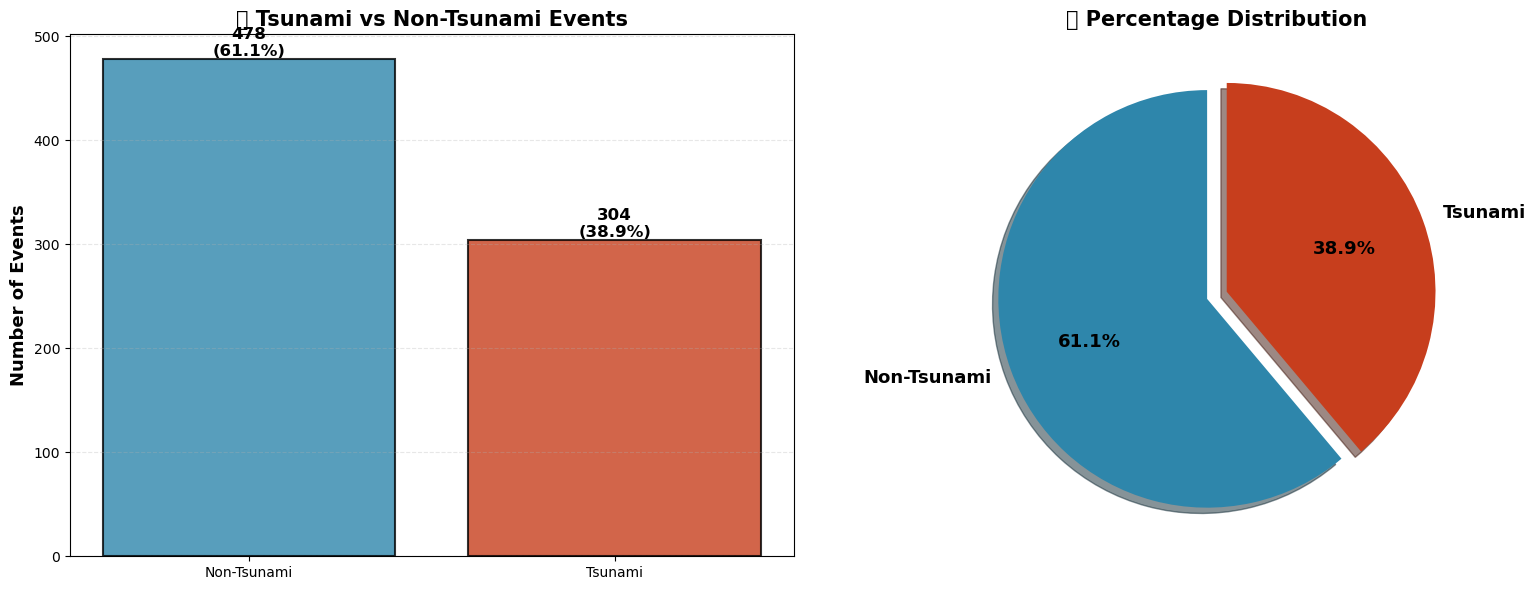

💡 KEY INSIGHTS: Target Distribution
✓ Dataset is moderately imbalanced (38.9% positive class)
✓ Non-Tsunami Events: 478 (61.1%)
✓ Tsunami Events: 304 (38.9%)
✓ Sufficient positive cases for robust model training
✓ Consider using stratified sampling and class-weighted models


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
tsunami_counts = df['tsunami'].value_counts().sort_index()
tsunami_pct = df['tsunami'].value_counts(normalize=True) * 100

colors = ['#2E86AB', '#C73E1D']
bars = axes[0].bar(['Non-Tsunami', 'Tsunami'], tsunami_counts.values, color=colors, 
                   edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Number of Events', fontsize=13, fontweight='bold')
axes[0].set_title('🎯 Tsunami vs Non-Tsunami Events', fontsize=15, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({height/tsunami_counts.sum()*100:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(tsunami_counts.values, labels=['Non-Tsunami', 'Tsunami'], autopct='%1.1f%%',
           colors=colors, startangle=90, explode=(0.05, 0.05), shadow=True,
           textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[1].set_title('📊 Percentage Distribution', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

# Key insights
print("="*70)
print("💡 KEY INSIGHTS: Target Distribution")
print("="*70)
print(f"✓ Dataset is moderately imbalanced ({tsunami_pct.iloc[1]:.1f}% positive class)")
print(f"✓ Non-Tsunami Events: {tsunami_counts.iloc[0]} ({tsunami_pct.iloc[0]:.1f}%)")
print(f"✓ Tsunami Events: {tsunami_counts.iloc[1]} ({tsunami_pct.iloc[1]:.1f}%)")
print(f"✓ Sufficient positive cases for robust model training")
print(f"✓ Consider using stratified sampling and class-weighted models")
print("="*70)

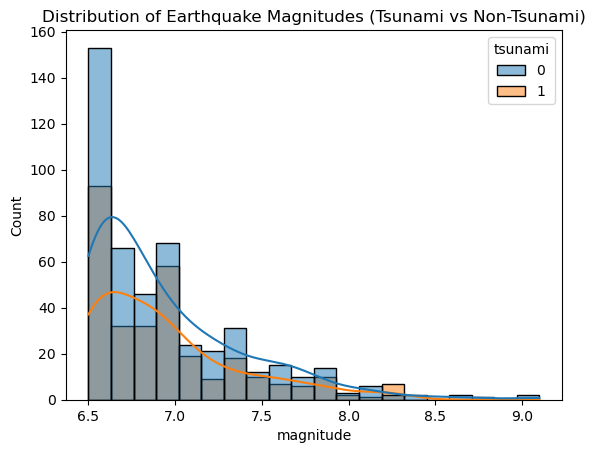

In [9]:
sns.histplot(data=df, x='magnitude', bins=20, kde=True, hue='tsunami')
plt.title('Distribution of Earthquake Magnitudes (Tsunami vs Non-Tsunami)')
plt.xlabel('magnitude')
plt.ylabel('Count')
plt.show()

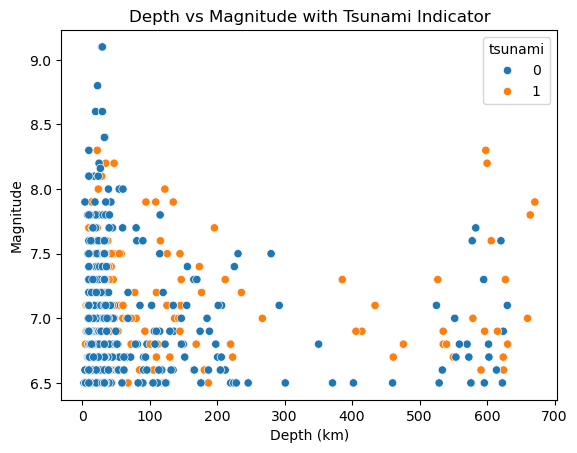

In [10]:
sns.scatterplot(data=df, x='depth', y='magnitude', hue='tsunami')
plt.title('Depth vs Magnitude with Tsunami Indicator')
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.show()

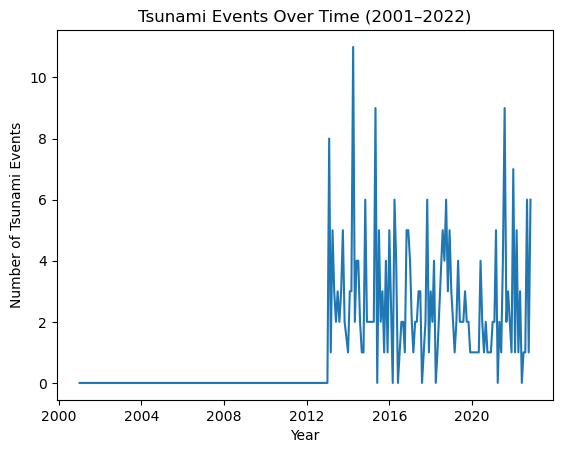

In [11]:
df['date'] = pd.to_datetime(df[['Year','Month']].assign(day=1))
sns.lineplot(data=df.groupby('date')['tsunami'].sum().reset_index(), x='date', y='tsunami')
plt.title('Tsunami Events Over Time (2001–2022)')
plt.xlabel('Year')
plt.ylabel('Number of Tsunami Events')
plt.show()

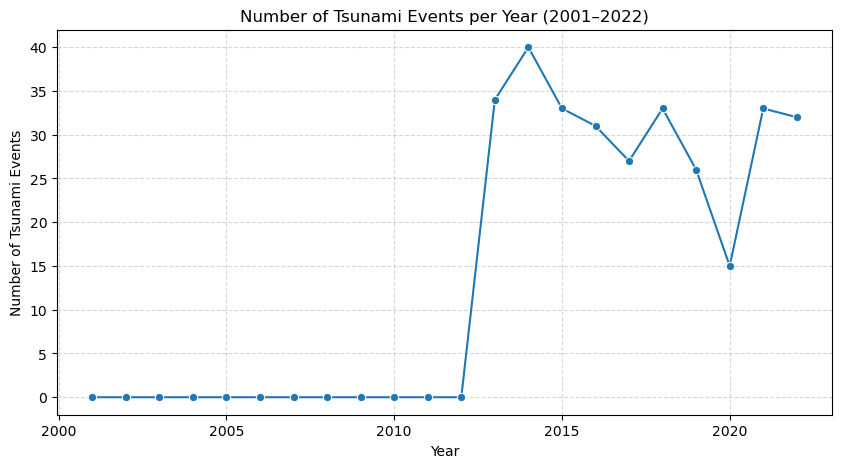

In [12]:
tsunami_per_year = df.groupby('Year')['tsunami'].sum().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=tsunami_per_year, x='Year', y='tsunami', marker='o')
plt.title('Number of Tsunami Events per Year (2001–2022)')
plt.xlabel('Year')
plt.ylabel('Number of Tsunami Events')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [13]:
plt.figure(figsize=(10,5))
sns.barplot(data=tsunami_per_month,x='Month',y='tsunami', hue='Month',palette='coolwarm',legend=False)
plt.title('Number of Tsunami Events per Month (2001–2022)')
plt.xlabel('Month')
plt.ylabel('Number of Tsunami Events')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

NameError: name 'tsunami_per_month' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='longitude', y='latitude', fill=True, cmap='coolwarm', alpha=0.7)
plt.title('Geographical Density of Earthquakes (2001–2022)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='nst', y='sig', hue='tsunami', palette='coolwarm', alpha=0.7)
plt.title('Stations Count vs Significance Index')
plt.xlabel('Number of Stations (nst)')
plt.ylabel('Significance (sig)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
df.isna().sum()

In [14]:
df.duplicated().sum()

0

In [15]:
print(df.nunique())

magnitude     24
cdi           10
mmi            9
sig          339
nst          312
dmin         369
gap          256
depth        303
latitude     778
longitude    777
Year          22
Month         12
tsunami        2
date         241
dtype: int64


In [16]:
def season_from_month(m):
    if m in [12, 1, 2]: return 'Winter'
    elif m in [3, 4, 5]: return 'Spring'
    elif m in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'
df['Season'] = df['Month'].apply(season_from_month)

In [17]:
df['abs_latitude'] = np.abs(df['latitude'])
df['equator_distance'] = np.abs(df['latitude'])
df['northern_hemisphere'] = (df['latitude'] > 0).astype(int)
df['pacific_region'] = ((df['longitude'] >= 120) | (df['longitude'] <= -60)).astype(int)

In [18]:
df['abs_latitude'] = np.abs(df['latitude'])
df['equator_distance'] = np.abs(df['latitude'])
df['northern_hemisphere'] = (df['latitude'] > 0).astype(int)
df['pacific_region'] = ((df['longitude'] >= 120) | (df['longitude'] <= -60)).astype(int)

In [19]:
df['Longitude_Zone'] = df['longitude'].apply(
    lambda x: 'Pacific' if -180 <= x <= -100 else
              'Atlantic' if -100 < x <= 20 else
              'Indian' if 20 < x <= 120 else
              'Other'
)
df['Hemisphere'] = df['latitude'].apply(lambda x: 'North' if x >= 0 else 'South')

In [20]:
df['is_shallow'] = (df['depth'] <= 70).astype(int)
df['is_very_shallow'] = (df['depth'] <= 35).astype(int)
def depth_category(d):
    if d <= 35:
        return 'Very High Risk'
    elif d <= 70:
        return 'High Risk'
    elif d <= 300:
        return 'Medium Risk'
    else:
        return 'Low Risk'
df['depth_risk_category'] = df['depth'].apply(depth_category)
df['Depth_Ratio'] = df['depth'] / df['depth'].mean()
df['mag_depth_ratio'] = df['magnitude'] / (df['depth'] + 1)
df['depth_squared'] = df['depth'] ** 2
df['log_depth'] = np.log1p(df['depth'])

In [21]:
df['is_major_quake'] = (df['magnitude'] >= 7.5).astype(int)
df['is_great_quake'] = (df['magnitude'] >= 8.0).astype(int)
def mag_category(m):
    if m < 4:
        return 'Weak'
    elif m < 6:
        return 'Moderate'
    elif m < 7:
        return 'Strong'
    elif m < 8:
        return 'Major'
    else:
        return 'Great'

df['Magnitude_Class'] = df['magnitude'].apply(mag_category)
df['magnitude_category'] = df['magnitude'].apply(mag_category)
df['magnitude_squared'] = df['magnitude'] ** 2
df['magnitude_cubed'] = df['magnitude'] ** 3
df['log_magnitude'] = np.log1p(df['magnitude'])

In [22]:
df['cdi_mmi_ratio'] = df['cdi'] / (df['mmi'] + 0.1)
df['intensity_product'] = df['cdi'] * df['mmi']
df['mag_sig_ratio'] = df['magnitude'] / (df['sig'] + 1)
df['Impact_Index'] = (df['magnitude'] * df['mmi'] * df['sig']) / (df['depth'] + 1)

In [23]:
df['network_coverage'] = df['nst'] / (df['gap'] + 1)
df['detection_quality'] = 1 / (df['dmin'] + 0.01)
df['log_nst'] = np.log1p(df['nst'])

In [24]:
df['Years_Since_2000'] = df['Year'] - 2000

In [25]:
df.select_dtypes(include='object').columns

Index(['Season', 'Longitude_Zone', 'Hemisphere', 'depth_risk_category',
       'Magnitude_Class', 'magnitude_category'],
      dtype='object')

In [26]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [27]:
df.head(5)

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,...,magnitude_cubed,log_magnitude,cdi_mmi_ratio,intensity_product,mag_sig_ratio,Impact_Index,network_coverage,detection_quality,log_nst,Years_Since_2000
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,...,343.000,2.079442,1.126761,56,0.009103,2508.800000,6.500000,1.926782,4.770685,22
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,...,328.509,2.066863,0.975610,16,0.009375,780.230769,2.828571,0.446628,4.605170,22
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,...,343.000,2.079442,0.967742,9,0.009259,27.336207,7.736842,0.318979,4.997212,22
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,...,389.017,2.116256,0.980392,25,0.008753,800.118421,6.772727,0.533333,5.010635,22
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,...,287.496,2.028148,0.000000,0,0.009836,14.139903,4.678571,0.199681,4.882802,22


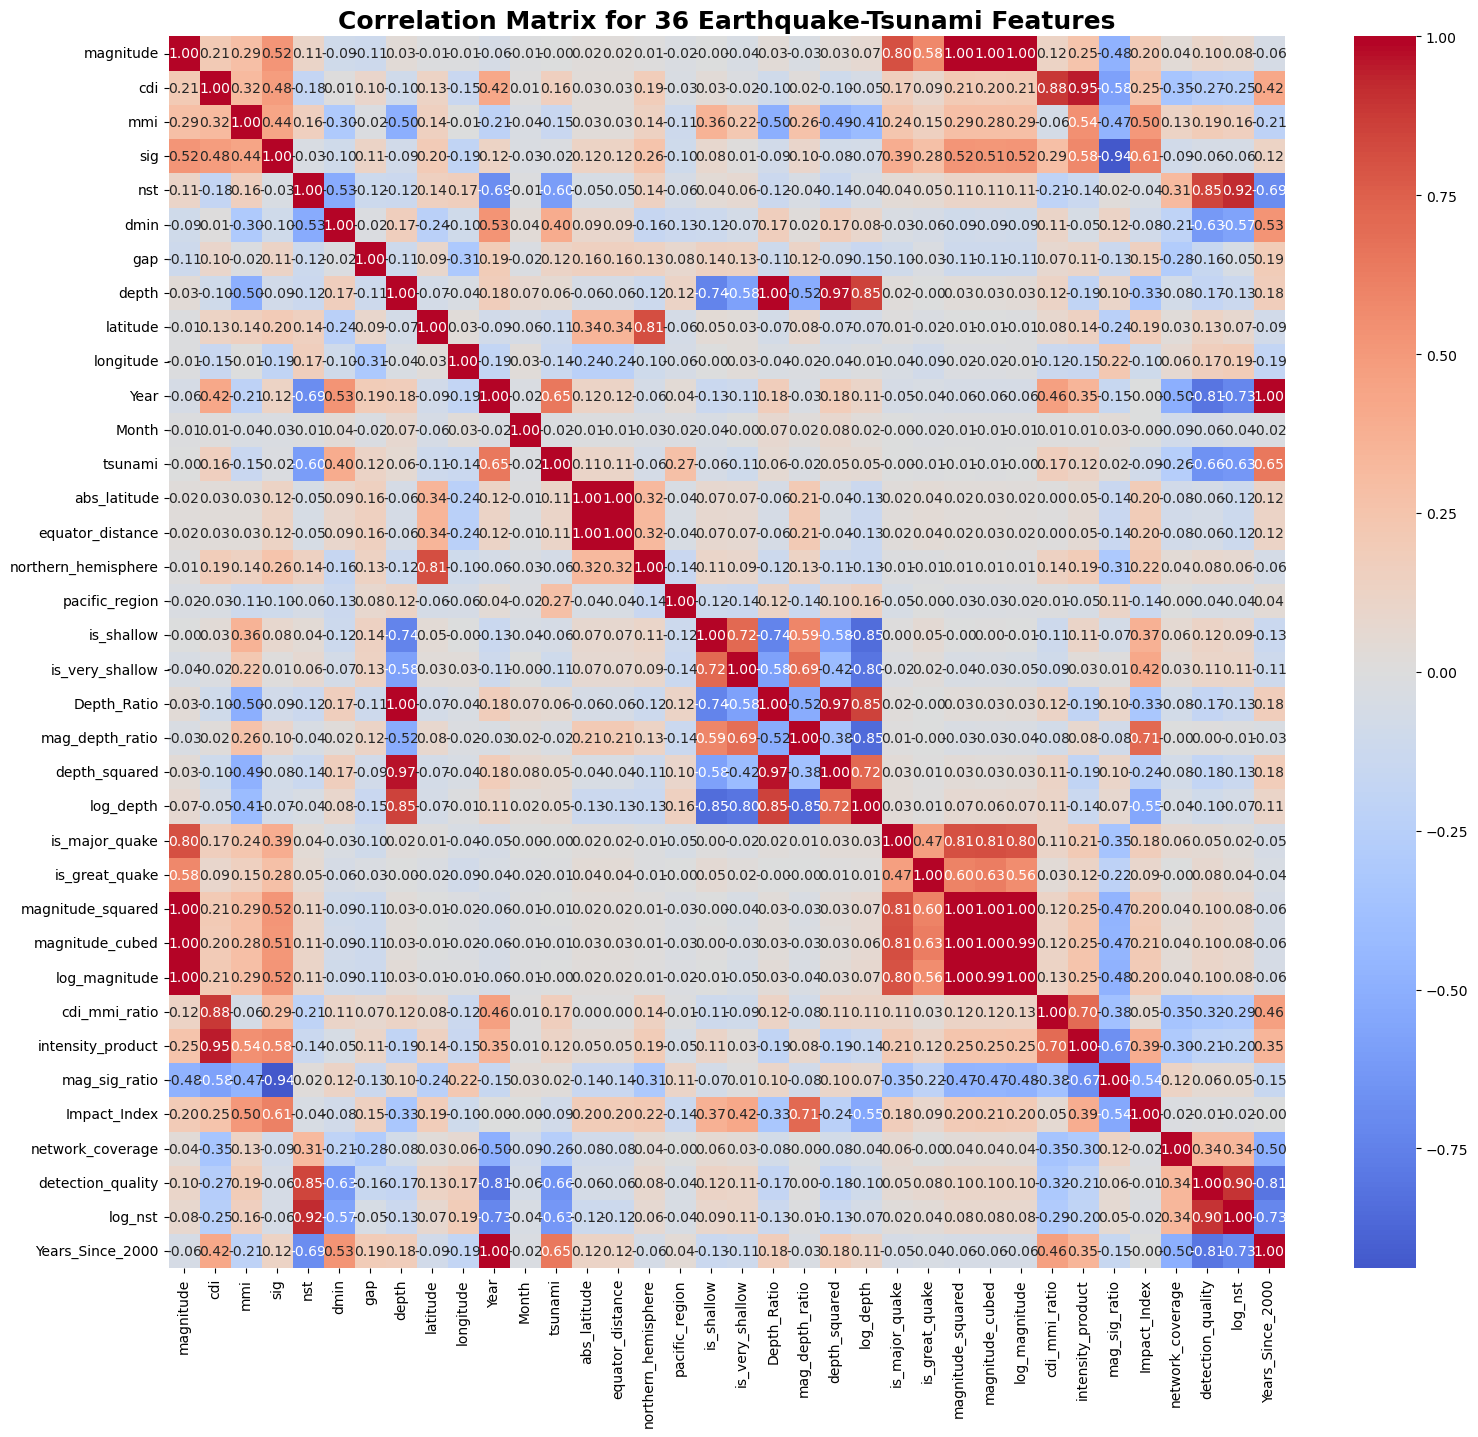

In [34]:
numeric_cols = ['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth','latitude', 'longitude', 'Year', 'Month', 'tsunami', 'abs_latitude',
'equator_distance', 'northern_hemisphere', 'pacific_region','is_shallow', 'is_very_shallow', 'Depth_Ratio', 'mag_depth_ratio','depth_squared', 
'log_depth', 'is_major_quake', 'is_great_quake','magnitude_squared', 'magnitude_cubed', 'log_magnitude','cdi_mmi_ratio', 'intensity_product', 
'mag_sig_ratio', 'Impact_Index','network_coverage', 'detection_quality', 'log_nst', 'Years_Since_2000']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(18,16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Matrix for 36 Earthquake-Tsunami Features", fontsize=18, fontweight='bold')
plt.show()

In [29]:
df.columns

Index(['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude', 'Year', 'Month', 'tsunami', 'date', 'Season',
       'abs_latitude', 'equator_distance', 'northern_hemisphere',
       'pacific_region', 'Longitude_Zone', 'Hemisphere', 'is_shallow',
       'is_very_shallow', 'depth_risk_category', 'Depth_Ratio',
       'mag_depth_ratio', 'depth_squared', 'log_depth', 'is_major_quake',
       'is_great_quake', 'Magnitude_Class', 'magnitude_category',
       'magnitude_squared', 'magnitude_cubed', 'log_magnitude',
       'cdi_mmi_ratio', 'intensity_product', 'mag_sig_ratio', 'Impact_Index',
       'network_coverage', 'detection_quality', 'log_nst', 'Years_Since_2000'],
      dtype='object')

In [35]:
#df.drop(['Year','Years_Since_2000','cdi','mmi','nst','dmin','gap','date', 'log_sig'],axis=1,inplace=True)

In [ ]:
#magnitude, depth, latitude, longitude, sig, Impact_Index, Equator_Dist, Longitude_Zone, Magnitude_Class, Depth_Ratio, log_depth, Depth_Mag_Rati

In [39]:
df.drop(['network_coverage','detection_quality','log_nst','Years_Since_2000','Longitude_Zone','Hemisphere','date','Season'],axis=1,inplace=True)

In [41]:
X=df.drop(['tsunami'],axis=1)
y=df['tsunami']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [42]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((625, 34), (157, 34), (625,), (157,))

In [43]:
y_train.value_counts(),y_test.value_counts()

(tsunami
 0    387
 1    238
 Name: count, dtype: int64,
 tsunami
 0    91
 1    66
 Name: count, dtype: int64)

In [44]:
#LogisticRegression
lg = LogisticRegression(class_weight='balanced', max_iter=1000)
lg.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [45]:
pred_lr=lg.predict(X_test)
print('ACCuracy',accuracy_score(y_test,pred_lr))
print('Precition',precision_score(y_test,pred_lr))
print('recall',recall_score(y_test,pred_lr))
print('confusion_matrix',confusion_matrix(y_test,pred_lr))

ACCuracy 0.8152866242038217
Precition 0.7228915662650602
recall 0.9090909090909091
confusion_matrix [[68 23]
 [ 6 60]]


In [46]:
#DecisionTreeClassifier
clf= DecisionTreeClassifier()
clf =clf.fit(X_train,y_train)

[Text(0.23335597826086957, 0.9642857142857143, 'x[10] <= 2012.5\ngini = 0.472\nsamples = 625\nvalue = [387.0, 238.0]'),
 Text(0.21161684782608695, 0.8928571428571429, 'gini = 0.0\nsamples = 294\nvalue = [294, 0]'),
 Text(0.22248641304347827, 0.9285714285714286, 'True  '),
 Text(0.25509510869565216, 0.8928571428571429, 'x[15] <= 0.5\ngini = 0.404\nsamples = 331\nvalue = [93, 238]'),
 Text(0.24422554347826086, 0.9285714285714286, '  False'),
 Text(0.08695652173913043, 0.8214285714285714, 'x[9] <= 11.36\ngini = 0.366\nsamples = 58\nvalue = [44, 14]'),
 Text(0.06521739130434782, 0.75, 'x[6] <= 63.0\ngini = 0.219\nsamples = 16\nvalue = [2, 14]'),
 Text(0.043478260869565216, 0.6785714285714286, 'x[13] <= 0.915\ngini = 0.124\nsamples = 15\nvalue = [1, 14]'),
 Text(0.021739130434782608, 0.6071428571428571, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.06521739130434782, 0.6071428571428571, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.08695652173913043, 0.6785714285714286, 'gini 

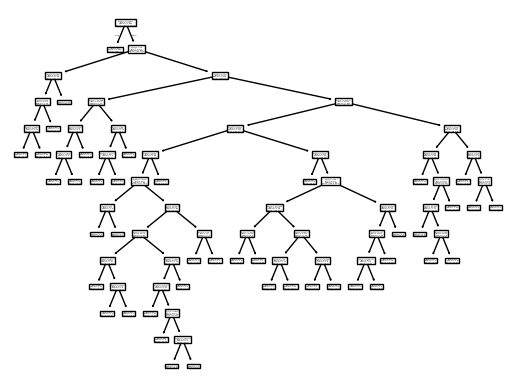

In [47]:
tree.plot_tree(clf)

In [48]:
#Feature Importance Analysis
importances = clf.feature_importances_
feature_importance = pd.Series(importances, index=X_train.columns)
important_features = feature_importance.sort_values(ascending=False)
print(important_features.head(10))

Year                   0.546242
pacific_region         0.108871
longitude              0.095738
mag_sig_ratio          0.041655
Impact_Index           0.033751
mag_depth_ratio        0.033673
latitude               0.029273
gap                    0.014024
dmin                   0.013284
northern_hemisphere    0.012726
dtype: float64


In [49]:
pred_clf = clf.predict(X_test)
print("precision",precision_score(y_test,pred_clf))
print("recall",recall_score(y_test,pred_clf))
print('confusion_matrix',confusion_matrix(y_test,pred_clf))

precision 0.9130434782608695
recall 0.9545454545454546
confusion_matrix [[85  6]
 [ 3 63]]


In [50]:
scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy:", scores.mean())

Cross-Validation Accuracy: 0.7126163645271926


In [51]:
#RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [52]:
print('ACCuracy',accuracy_score(y_test,pred_rf))
print('Precition',precision_score(y_test,pred_rf))
print('recall',recall_score(y_test,pred_rf))
print('confusion_matrix',confusion_matrix(y_test,pred_rf))

ACCuracy 0.9171974522292994
Precition 0.8840579710144928
recall 0.9242424242424242
confusion_matrix [[83  8]
 [ 5 61]]


In [53]:
#XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [54]:
pred_xgb= xgb.predict(X_test)
print('ACCuracy',accuracy_score(y_test,pred_xgb))
print('Precition',precision_score(y_test,pred_xgb))
print('recall',recall_score(y_test,pred_xgb))
print('confusion_matrix',confusion_matrix(y_test,pred_xgb))

ACCuracy 0.9426751592356688
Precition 0.9253731343283582
recall 0.9393939393939394
confusion_matrix [[86  5]
 [ 4 62]]


In [55]:
#SVM
svm=SVC()
svm.fit(X_train,y_train)

SVC()

In [56]:
pred_svm=svm.predict(X_test)
print('ACCuracy',accuracy_score(y_test,pred_svm))
print('Precition',precision_score(y_test,pred_svm))
print('recall',recall_score(y_test,pred_svm))
print('confusion_matrix',confusion_matrix(y_test,pred_svm))

ACCuracy 0.5668789808917197
Precition 0.25
recall 0.015151515151515152
confusion_matrix [[88  3]
 [65  1]]


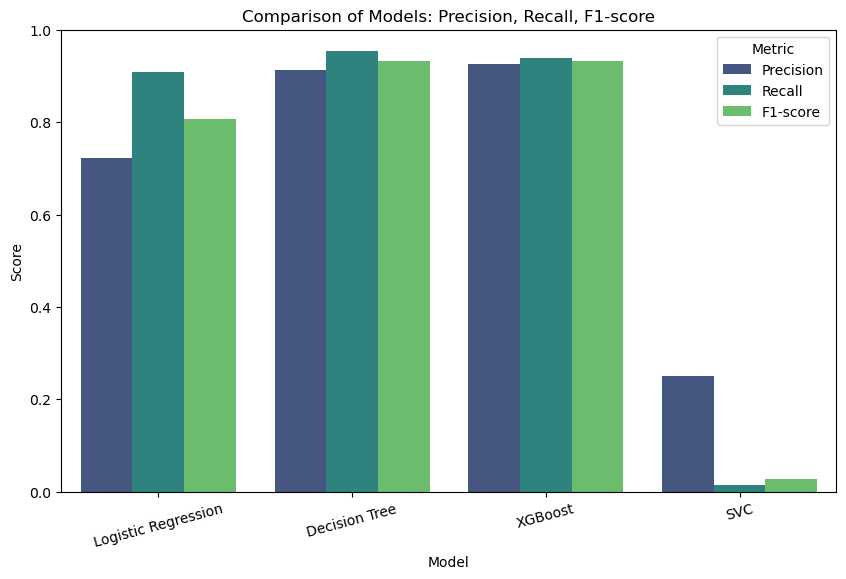

In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# إنشاء DataFrame بالمقاييس
data = {'Model': ['Logistic Regression', 'Decision Tree', 'XGBoost', 'SVC'],
'Accuracy': [0.8153, 0.9427, 0.9427, 0.5669],
'Precision': [0.7229, 0.9130, 0.9254, 0.25],
'Recall': [0.9091, 0.9545, 0.9394, 0.0152],
'F1-score': [0.8077, 0.9332, 0.9323, 0.0283]
}
df_metrics = pd.DataFrame(data)
df_plot = pd.melt(df_metrics, id_vars='Model', value_vars=['Precision', 'Recall', 'F1-score'],var_name='Metric', value_name='Score')
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_plot, palette='viridis')
plt.ylim(0, 1)
plt.title('Comparison of Models: Precision, Recall, F1-score')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(title='Metric')
plt.show()